In [22]:
# Cell 1: استكشاف /kaggle/input
import os
from pathlib import Path, PurePath
root = "/kaggle/input"

print("Top-level datasets:")
for entry in sorted(os.listdir(root)):
    p = os.path.join(root, entry)
    print("-", entry, "(dir)" if os.path.isdir(p) else "(file)")
    if os.path.isdir(p):
        sample = os.listdir(p)[:8]
        print("   sample:", sample)

# بحث عن ملفات شائعة
matches = []
for dirpath, dirnames, filenames in os.walk(root):
    for fn in filenames:
        if fn.lower() in ("train.csv","test.csv","sample_submission.csv","_annotations.coco.json","instances_train.json"):
            matches.append(os.path.join(dirpath, fn))
print("\nFound common files:")
for m in matches: print("-", m)


Top-level datasets:
- taco-trash-detection-yolo12n (dir)
   sample: ['__results__.html', '__notebook__.ipynb', '__results___files', '__output__.json', 'custom.css']
- vignette-ocr (dir)
   sample: ['sample_submission.csv', 'train.csv', 'test.csv', 'test', 'train']
- yolo-v8-and-easyocr (dir)
   sample: ['easyocr_models', '__results__.html', '__notebook__.ipynb', 'wheels', 'yolov8n.pt', '__output__.json', 'custom.css']

Found common files:
- /kaggle/input/vignette-ocr/sample_submission.csv
- /kaggle/input/vignette-ocr/train.csv
- /kaggle/input/vignette-ocr/test.csv
- /kaggle/input/vignette-ocr/train/_annotations.coco.json


In [23]:
import json
import os
import random
from pathlib import Path
import shutil

# المسارات
INPUT = '/kaggle/input/vignette-ocr/train'   # الصور الأصلية
WORK = '/kaggle/working'
COCO_JSON = os.path.join(INPUT, '_annotations.coco.json')

# تحميل COCO JSON
with open(COCO_JSON, 'r', encoding='utf-8') as f:
    coco = json.load(f)

# إنشاء مجلدات train/val النهائية
train_dir = os.path.join(WORK, 'train')
val_dir = os.path.join(WORK, 'val')
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# بناء dict للصور
images_info = {img['id']: img for img in coco['images']}

# Category mapping
cat_name_to_id = {cat['name']: i for i, cat in enumerate(coco['categories'])}

# إنشاء ملفات TXT مؤقتة لكل annotation
labels_tmp_dir = os.path.join(WORK, 'labels_tmp')
os.makedirs(labels_tmp_dir, exist_ok=True)

for ann in coco['annotations']:
    img_info = images_info[ann['image_id']]
    fname = img_info['file_name']
    img_w, img_h = img_info['width'], img_info['height']

    x, y, w, h = ann['bbox']
    x_center = (x + w/2) / img_w
    y_center = (y + h/2) / img_h
    w_n = w / img_w
    h_n = h / img_h

    cat_name = next((c['name'] for c in coco['categories'] if c['id']==ann['category_id']), None)
    cls = cat_name_to_id.get(cat_name, 0)

    label_path = os.path.join(labels_tmp_dir, Path(fname).stem + '.txt')
    with open(label_path, 'a', encoding='utf-8') as f:
        f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w_n:.6f} {h_n:.6f}\n")

# جمع كل الصور التي لها labels
all_labelled_images = [f.replace('.txt', '.jpg') for f in os.listdir(labels_tmp_dir) if f.endswith('.txt')]

# عمل split 80/20
random.seed(42)
random.shuffle(all_labelled_images)
split_idx = int(0.8 * len(all_labelled_images))
train_imgs = all_labelled_images[:split_idx]
val_imgs = all_labelled_images[split_idx:]

# نسخ الصور والليبلز مباشرة في train و val
for img_file in train_imgs:
    shutil.copy(os.path.join(INPUT, img_file), os.path.join(train_dir, img_file))
    shutil.copy(os.path.join(labels_tmp_dir, Path(img_file).stem + '.txt'), os.path.join(train_dir, Path(img_file).stem + '.txt'))

for img_file in val_imgs:
    shutil.copy(os.path.join(INPUT, img_file), os.path.join(val_dir, img_file))
    shutil.copy(os.path.join(labels_tmp_dir, Path(img_file).stem + '.txt'), os.path.join(val_dir, Path(img_file).stem + '.txt'))

print(f"Train images: {len(train_imgs)}, Val images: {len(val_imgs)}")


Train images: 600, Val images: 150


In [24]:
# فحص الليبلز داخل نفس مجلد الصور
def check_labels(images_dir):
    images = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
    missing_labels = []
    for img in images:
        label_file = os.path.join(images_dir, os.path.splitext(img)[0] + '.txt')
        if not os.path.exists(label_file):
            missing_labels.append(img)
    if missing_labels:
        print(f"{len(missing_labels)} images missing labels in {images_dir}:")
        print(missing_labels[:10], '...')
    else:
        print(f"All {len(images)} images in {images_dir} have corresponding labels.")

check_labels(train_dir)
check_labels(val_dir)


122 images missing labels in /kaggle/working/train:
['WIN_20200702_19_08_05_Pro_jpg.rf.7cc9f157dcfb14fe7310f8f539c4ec8d.jpg', 'WIN_20200702_18_51_31_Pro_jpg.rf.ce51e8db3745659bcbc030bfdd153fe0.jpg', 'WIN_20200702_16_53_20_Pro_jpg.rf.5e1d43b1ae062e11e6520d3f0be41a9a.jpg', 'WIN_20200703_11_18_54_Pro_jpg.rf.3a710f57f974c18ec8a3ad2e9f341f00.jpg', 'WIN_20200702_15_45_33_Pro_jpg.rf.afa0d9711b2550bde02380021206cf85.jpg', 'WIN_20200702_14_59_00_Pro_jpg.rf.1e682be3fd822cae917e1b448315c47f.jpg', 'WIN_20200702_15_53_25_Pro_jpg.rf.8560040f02920afda3d7e38d462dc48e.jpg', 'WIN_20200702_19_27_09_Pro_jpg.rf.1aa75cbe347803e619cebb43e4256b05.jpg', 'WIN_20200702_17_52_52_Pro_jpg.rf.ec4c296e74cfb0d9f20b25132b098271.jpg', 'WIN_20200702_18_12_14_Pro_jpg.rf.f3774185743e51567cbf43a437e95e3c.jpg'] ...
122 images missing labels in /kaggle/working/val:
['WIN_20200702_18_05_04_Pro_jpg.rf.240d97b6ebb1346f58d2d82873393fe3.jpg', 'WIN_20200703_11_12_23_Pro_jpg.rf.43a3cae1f7c7bd1cb99e6a33af076d2e.jpg', 'WIN_20200702_17

In [25]:
# Cell B: Safe fix — convert old labels (1/2) -> 0/1 if needed
import os
from pathlib import Path
import shutil

nc = 2
folders = {
    'train': '/kaggle/working/train',
    'val':   '/kaggle/working/val'
}

def fix_folder(folder):
    if not os.path.exists(folder):
        print("Folder not found:", folder); return
    txt_files = list(Path(folder).glob('*.txt'))
    # gather classes
    cls_set = set()
    for f in txt_files:
        with open(f, 'r', encoding='utf-8') as fh:
            for ln in fh:
                ln = ln.strip()
                if not ln: continue
                parts = ln.split()
                try:
                    cls = int(float(parts[0]))
                    cls_set.add(cls)
                except:
                    pass
    if not cls_set:
        print(f"[{folder}] No numeric classes found — skipping.")
        return
    max_cls = max(cls_set)
    print(f"[{folder}] classes found: {sorted(cls_set)}  max={max_cls}")
    # Decide fix rule:
    if max_cls == nc:
        # apply mapping: new_cls = cls-1 for cls>0, keep 0
        print(f"[{folder}] Applying transform: new_cls = cls-1 for cls>0")
        changed_files = 0
        for f in txt_files:
            modified = False
            lines_out = []
            with open(f, 'r', encoding='utf-8') as fh:
                for ln in fh:
                    ln = ln.strip()
                    if not ln:
                        continue
                    parts = ln.split()
                    try:
                        cls = int(float(parts[0]))
                        if cls > 0:
                            new_cls = cls - 1
                            modified = modified or (new_cls != cls)
                        else:
                            new_cls = 0
                        rest = parts[1:5]
                        lines_out.append(f"{new_cls} " + " ".join(rest))
                    except Exception as e:
                        # keep original line if parse fail
                        lines_out.append(ln)
            if modified:
                # backup original
                shutil.copy2(f, str(f) + '.bak')
                with open(f, 'w', encoding='utf-8') as fo:
                    fo.write("\n".join(lines_out) + ("\n" if lines_out else ""))
                changed_files += 1
        print(f"[{folder}] Done. Files changed: {changed_files}. Backups saved with .bak")
    else:
        # if max_cls < nc -> nothing to do
        if max_cls < nc:
            print(f"[{folder}] max class < nc -> nothing to fix.")
        else:
            # Unexpected larger classes: print sample files for manual inspection
            print(f"[{folder}] Unexpected max class > nc ({max_cls} > {nc}). Will NOT auto-fix.")
            sample = txt_files[:10]
            for s in sample:
                print("Sample:", s)
                with open(s, 'r', encoding='utf-8') as fh:
                    print(" ", fh.read().strip().splitlines()[:5])

# Run fixer
for name, folder in folders.items():
    fix_folder(folder)

print("Finished fixing step. Now re-run the diagnostic cell (Cell A) to verify.")


[/kaggle/working/train] classes found: [1, 2]  max=2
[/kaggle/working/train] Applying transform: new_cls = cls-1 for cls>0
[/kaggle/working/train] Done. Files changed: 600. Backups saved with .bak
[/kaggle/working/val] classes found: [1, 2]  max=2
[/kaggle/working/val] Applying transform: new_cls = cls-1 for cls>0
[/kaggle/working/val] Done. Files changed: 150. Backups saved with .bak
Finished fixing step. Now re-run the diagnostic cell (Cell A) to verify.


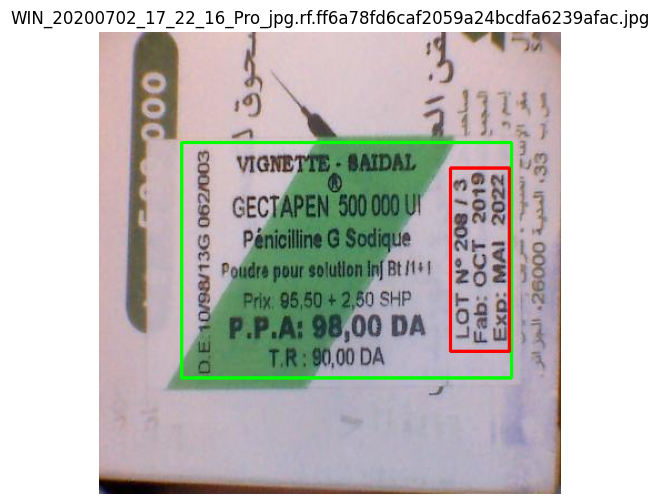

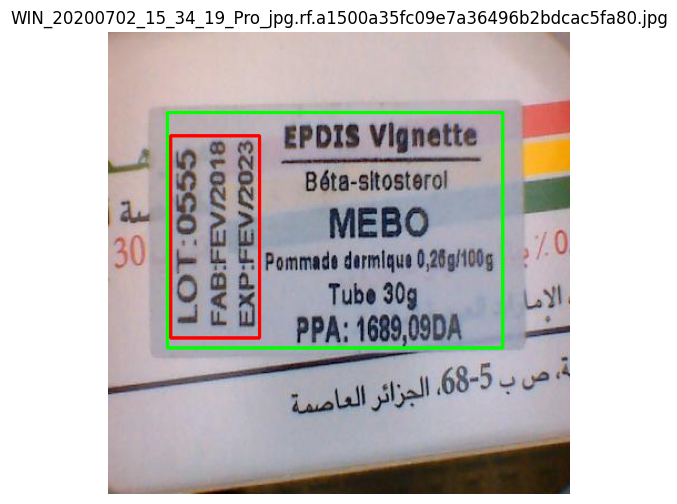

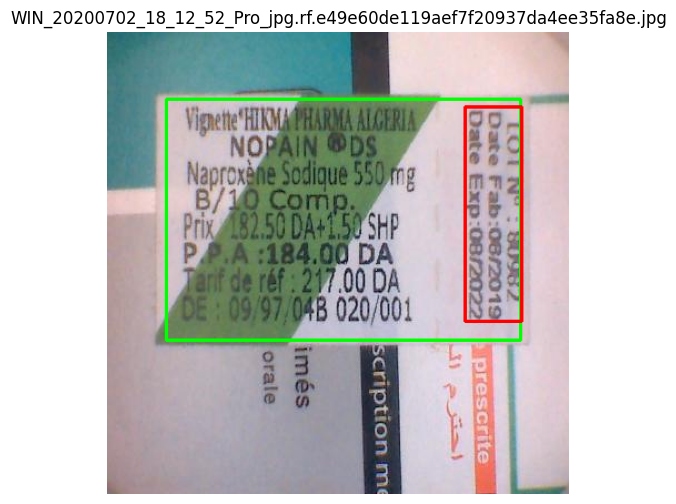

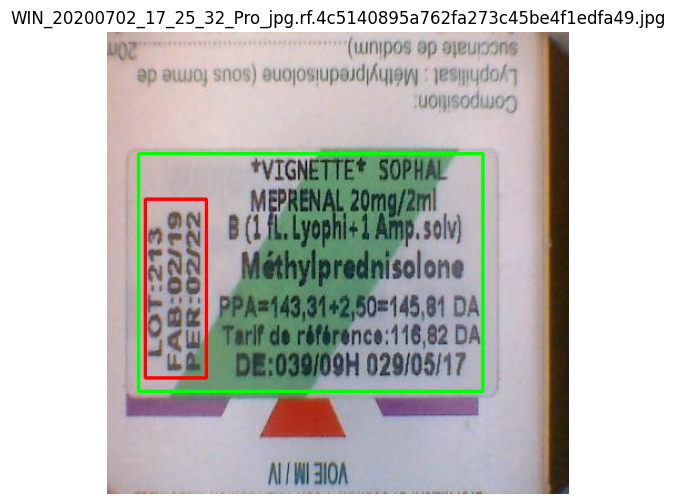

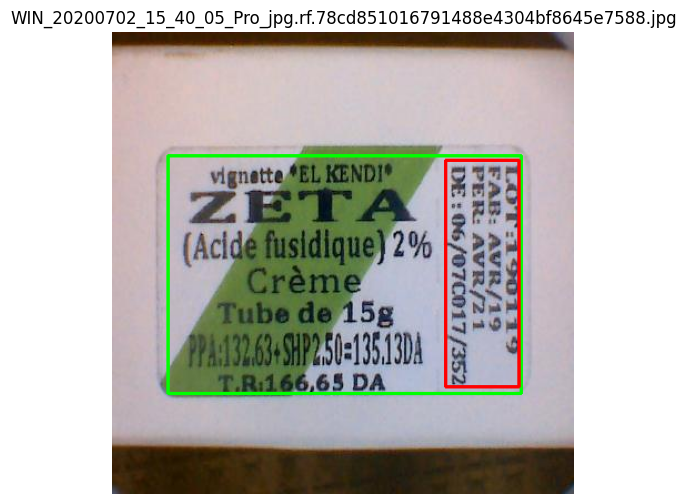

In [26]:
import cv2
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt

# مجلد للتأكد منه
check_dir = '/kaggle/working/train'  # جرب أيضًا '/kaggle/working/val'

# اختيار 5 صور عشوائية
all_images = [f for f in os.listdir(check_dir) if f.endswith('.jpg')]
sample_images = random.sample(all_images, 5)

for img_file in sample_images:
    img_path = os.path.join(check_dir, img_file)
    label_path = os.path.join(check_dir, Path(img_file).stem + '.txt')
    
    # قراءة الصورة
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # قراءة ملف txt ورسم الـ bounding boxes
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls, x_center, y_center, bw, bh = map(float, line.strip().split())
                # تحويل القيم من النسب إلى بيكسل
                x1 = int((x_center - bw/2) * w)
                y1 = int((y_center - bh/2) * h)
                x2 = int((x_center + bw/2) * w)
                y2 = int((y_center + bh/2) * h)
                color = (255, 0, 0) if int(cls)==0 else (0, 255, 0)  # entete: أزرق، vin: أخضر
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    
    # عرض الصورة مع الـ bounding boxes
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(img_file)
    plt.axis('off')
    plt.show()


In [27]:
from collections import defaultdict
import json

with open('/kaggle/input/vignette-ocr/train/_annotations.coco.json', 'r') as f:
    coco = json.load(f)

img_count = defaultdict(int)
for ann in coco['annotations']:
    img_count[ann['image_id']] += 1

# بعض الأمثلة
for img_id, count in list(img_count.items())[:10]:
    print(f"Image ID {img_id} has {count} annotations")


Image ID 0 has 2 annotations
Image ID 1 has 2 annotations
Image ID 2 has 2 annotations
Image ID 3 has 2 annotations
Image ID 4 has 2 annotations
Image ID 5 has 2 annotations
Image ID 6 has 2 annotations
Image ID 7 has 2 annotations
Image ID 8 has 2 annotations
Image ID 9 has 2 annotations


In [28]:
import os
from pathlib import Path

# مجلدات الصور والليبلز
train_images_dir = '/kaggle/working/train'
val_images_dir   = '/kaggle/working/val'
train_labels_dir = '/kaggle/working/train'
val_labels_dir   = '/kaggle/working/val'


def check_missing_labels(images_dir, labels_dir):
    all_images = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
    missing_txt = []
    for img_file in all_images:
        label_file = os.path.join(labels_dir, Path(img_file).stem + '.txt')
        if not os.path.exists(label_file):
            missing_txt.append(img_file)
    return missing_txt

# التحقق من Train
train_missing = check_missing_labels(train_images_dir, train_labels_dir)
print(f"عدد صور Train بدون ملفات TXT: {len(train_missing)}")
if train_missing:
    print("أمثلة على بعض صور Train بدون ملفات TXT:", train_missing[:10])

# التحقق من Val
val_missing = check_missing_labels(val_images_dir, val_labels_dir)
print(f"عدد صور Val بدون ملفات TXT: {len(val_missing)}")
if val_missing:
    print("أمثلة على بعض صور Val بدون ملفات TXT:", val_missing[:10])


عدد صور Train بدون ملفات TXT: 122
أمثلة على بعض صور Train بدون ملفات TXT: ['WIN_20200702_19_08_05_Pro_jpg.rf.7cc9f157dcfb14fe7310f8f539c4ec8d.jpg', 'WIN_20200702_18_51_31_Pro_jpg.rf.ce51e8db3745659bcbc030bfdd153fe0.jpg', 'WIN_20200702_16_53_20_Pro_jpg.rf.5e1d43b1ae062e11e6520d3f0be41a9a.jpg', 'WIN_20200703_11_18_54_Pro_jpg.rf.3a710f57f974c18ec8a3ad2e9f341f00.jpg', 'WIN_20200702_15_45_33_Pro_jpg.rf.afa0d9711b2550bde02380021206cf85.jpg', 'WIN_20200702_14_59_00_Pro_jpg.rf.1e682be3fd822cae917e1b448315c47f.jpg', 'WIN_20200702_15_53_25_Pro_jpg.rf.8560040f02920afda3d7e38d462dc48e.jpg', 'WIN_20200702_19_27_09_Pro_jpg.rf.1aa75cbe347803e619cebb43e4256b05.jpg', 'WIN_20200702_17_52_52_Pro_jpg.rf.ec4c296e74cfb0d9f20b25132b098271.jpg', 'WIN_20200702_18_12_14_Pro_jpg.rf.f3774185743e51567cbf43a437e95e3c.jpg']
عدد صور Val بدون ملفات TXT: 122
أمثلة على بعض صور Val بدون ملفات TXT: ['WIN_20200702_18_05_04_Pro_jpg.rf.240d97b6ebb1346f58d2d82873393fe3.jpg', 'WIN_20200703_11_12_23_Pro_jpg.rf.43a3cae1f7c7bd1cb

In [29]:
# Cell 2: Install offline wheels (if not already installed)
print("Installing local wheels (if needed)...")
!pip install --no-index --find-links=/kaggle/input/yolo-v8-and-easyocr/wheels/ ultralytics easyocr opencv-python-headless || true
print("Done.")


Installing local wheels (if needed)...
Looking in links: /kaggle/input/yolo-v8-and-easyocr/wheels/
Done.


In [31]:
# Cell 3: Imports + load models paths (no heavy init yet)
import os, json, re
import cv2
from pathlib import Path

# paths (تعدّل لو حبيت)
INPUT = '/kaggle/input/vignette-ocr'
MODEL_INPUT = '/kaggle/input/yolo-v8-and-easyocr'
WORK = '/kaggle/working'

print("INPUT exists:", os.path.exists(INPUT))
print("MODEL_INPUT exists:", os.path.exists(MODEL_INPUT))
print("Working dir:", WORK)

# local model files
yolo_pt = os.path.join(MODEL_INPUT, 'yolov8n.pt')
easyocr_models = os.path.join(MODEL_INPUT, 'easyocr_models')
print("yolo_pt:", yolo_pt, "exists:", os.path.exists(yolo_pt))
print("easyocr_models:", easyocr_models, "exists:", os.path.exists(easyocr_models))


INPUT exists: True
MODEL_INPUT exists: True
Working dir: /kaggle/working
yolo_pt: /kaggle/input/yolo-v8-and-easyocr/yolov8n.pt exists: True
easyocr_models: /kaggle/input/yolo-v8-and-easyocr/easyocr_models exists: True


In [32]:
import os
import random
import shutil

# مجلد البيانات الأصلية بعد التحميل
INPUT = '/kaggle/input/vignette-ocr/train'  # غيّر حسب مكان صورك
WORK = '/kaggle/working'                # مكان العمل

train_images_dir = INPUT
all_images = [f for f in os.listdir(train_images_dir) if f.endswith('.jpg')]

# نختار 20% عشوائيًا كـ validation
val_count = int(0.2 * len(all_images))
val_images = random.sample(all_images, val_count)
train_images = list(set(all_images) - set(val_images))

# إنشاء مجلدات جديدة
os.makedirs(os.path.join(WORK, 'train'), exist_ok=True)
os.makedirs(os.path.join(WORK, 'val'), exist_ok=True)

# نسخ الصور إلى المجلدات
for f in train_images:
    shutil.copy(os.path.join(INPUT, f), os.path.join(WORK, 'train', f))
for f in val_images:
    shutil.copy(os.path.join(INPUT, f), os.path.join(WORK, 'val', f))

print(f"Train images: {len(train_images)}, Val images: {len(val_images)}")


Train images: 600, Val images: 150


In [33]:
# مجلد labels المصدر من تحويل COCO إلى YOLO (إذا حولتها مسبقًا)
labels_src_dir = os.path.join(WORK, 'labels', 'train')
labels_train_dir = os.path.join(WORK, 'train', 'labels')
labels_val_dir = os.path.join(WORK, 'val', 'labels')

os.makedirs(labels_train_dir, exist_ok=True)
os.makedirs(labels_val_dir, exist_ok=True)

# نسخ ملفات labels الخاصة بالـ train
for f in train_images:
    label_file = os.path.join(labels_src_dir, f.replace('.jpg', '.txt'))
    if os.path.exists(label_file):
        shutil.copy(label_file, os.path.join(labels_train_dir, f.replace('.jpg', '.txt')))
    else:
        # إذا الصورة بدون label، نتركها بدون ملف
        open(os.path.join(labels_train_dir, f.replace('.jpg', '.txt')), 'w').close()

# إنشاء ملفات فارغة للـ val (لأنها بدون labels)
for f in val_images:
    open(os.path.join(labels_val_dir, f.replace('.jpg', '.txt')), 'w').close()

print("Labels folders ready:")
print(f"Train labels: {len(os.listdir(labels_train_dir))}")
print(f"Val labels: {len(os.listdir(labels_val_dir))}")


Labels folders ready:
Train labels: 607
Val labels: 157


In [34]:
from pathlib import Path
import os

def validate_labels(images_folder):
    bad = []
    for fn in os.listdir(images_folder):
        if fn.endswith('.txt'):
            p = Path(images_folder) / fn
            with open(p, 'r', encoding='utf-8') as f:
                lines = [l.strip() for l in f if l.strip()]
            for i, ln in enumerate(lines, 1):
                parts = ln.split()
                if len(parts) != 5:
                    bad.append((fn, i, 'ncols', parts))
                    continue
                try:
                    cls = int(float(parts[0]))
                    coords = list(map(float, parts[1:5]))
                    for c in coords:
                        if not (0.0 <= c <= 1.0):
                            bad.append((fn, i, 'range', coords))
                            break
                except Exception as e:
                    bad.append((fn, i, 'parse', str(e)))
    return bad


# المسارات الصحيحة
train_dir = "/kaggle/working/train"
val_dir   = "/kaggle/working/val"

# تحقق من TRAIN
print("Checking TRAIN labels...")
train_bad = validate_labels(train_dir)
print("Bad label examples (Train):", train_bad[:10] if train_bad else "All good!")

# تحقق من VAL
print("\nChecking VAL lab")


Checking TRAIN labels...
Bad label examples (Train): All good!

Checking VAL lab


In [35]:
# المسارات الصحيحة لمجلدات Train و Val
train_dir = "/kaggle/working/train"
val_dir   = "/kaggle/working/val"

# إنشاء data.yaml
data_yaml = f"""
train: {train_dir}
val:   {val_dir}
nc: 2
names: ['entete','vin']
""".strip()

yaml_path = os.path.join("/kaggle/working", "data.yaml")
with open(yaml_path, 'w', encoding='utf-8') as f:
    f.write(data_yaml)

print("Created data.yaml at", yaml_path)
print("---\n", data_yaml)


Created data.yaml at /kaggle/working/data.yaml
---
 train: /kaggle/working/train
val:   /kaggle/working/val
nc: 2
names: ['entete','vin']


# yolo8

In [36]:
# Cell: safe load + train YOLOv8 (مصحّح)
import os
from ultralytics import YOLO

# 1) اعرض مجلد /kaggle/input للتأكد من مكان الملف الفعلي
print("Listing /kaggle/input contents:")
for name in sorted(os.listdir("/kaggle/input")):
    print(" -", name)

# بعض المواقع المحتملة للـ .pt (جرب كل واحد منهم)
candidates = [
    "/kaggle/input/yolo-v8-and-easyocr/yolov8n.pt",
    "/kaggle/input/yolov8n-pt/yolov8n.pt",
    "/kaggle/input/yolov8n/yolov8n.pt",
    "/kaggle/input/yolov8/yolov8n.pt",
    # أضف هنا أي مسار آخر تظنّه صحيح
]

yolo_pt = None
for p in candidates:
    if os.path.isfile(p):
        yolo_pt = p
        break

# إذا لم نجد ملفًا في القوائم الافتراضية، حاول البحث تلقائياً داخل /kaggle/input
if yolo_pt is None:
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            if f.lower().endswith(".pt"):
                yolo_pt = os.path.join(root, f)
                break
        if yolo_pt:
            break

print("\nDetected yolo .pt:", yolo_pt)

if yolo_pt is None:
    raise FileNotFoundError("لم أجد ملف .pt داخل /kaggle/input. ارفع ملف weight (yolov8n.pt) أو حدّد المسار الصحيح.")

# 2) تأكد أن ملف data.yaml موجود
yaml_path = "/kaggle/working/data.yaml"
if not os.path.isfile(yaml_path):
    raise FileNotFoundError(f"data.yaml غير موجود في المسار المتوقع: {yaml_path}\nأنشئه أولاً أو حدّث المسار.")

print("Using data.yaml:", yaml_path)

# 3) تحميل النموذج من الملف المحلي (لا يحاول التنزيل لأن الملف محلي)
try:
    model = YOLO(yolo_pt)
    print("Model loaded from local .pt successfully.")
except Exception as e:
    # أخطَر تحميل النموذج: نطبع الخطأ ونعطي خيار التشغيل على CPU
    print("Error loading model from local .pt:", e)
    print("Attempting to load model on CPU fallback...")
    os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU
    model = YOLO(yolo_pt)
    print("Model loaded on CPU.")

# 4) تدريب (عدّل epochs, batch حسب مواردك)
model.train(
    data=yaml_path,
    epochs=30,
    imgsz=416,
    batch=8,  # لو CPU ضع 2 أو 4
    project="/kaggle/working/yolov8-runs",
    name="drug_sticker_ocr_clean"
)


Listing /kaggle/input contents:
 - taco-trash-detection-yolo12n
 - vignette-ocr
 - yolo-v8-and-easyocr

Detected yolo .pt: /kaggle/input/yolo-v8-and-easyocr/yolov8n.pt
Using data.yaml: /kaggle/working/data.yaml
Model loaded from local .pt successfully.
New https://pypi.org/project/ultralytics/8.3.233 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.221 🚀 Python-3.11.13 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        278        303      0.538      0.987      0.564      0.506
                entete        150        152      0.538       0.98      0.541      0.454
                   vin        150        151      0.539      0.993      0.588      0.558
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /kaggle/working/yolov8-runs/drug_sticker_ocr_clean2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79b096280110>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

# -----------------------------------------------------------------------

# inference

In [ ]:
# اعرض Predictions لبعض الصور من مجلد val
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
model = YOLO('/kaggle/working/yolov8-runs/drug_sticker_ocr_clean/weights/best.pt')  # أو آخر وزن

val_images = sorted(os.listdir('/kaggle/working/val'))[:12]  # أو اختار أي قائمة
plt.figure(figsize=(12,8))
for i, img_name in enumerate(val_images[:6]):
    img_path = os.path.join('/kaggle/working/val', img_name)
    res = model.predict(source=img_path, conf=0.25, save=False, verbose=False)[0]
    img = cv2.imread(img_path)
    for box in res.boxes.xyxy.cpu().numpy():
        x1,y1,x2,y2 = map(int, box[:4])
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    plt.subplot(2,3,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()


In [ ]:
# Visualize predictions + ground-truth for many images (robust - use numpy input)
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# المسارات — عدّل لوين عملت نسخ الصور/ليبلز
VAL_DIR = '/kaggle/working/val'                # مجلد الصور المراد فحصها
LABELS_DIR = '/kaggle/working/labels/val'      # مجلد ملفات الـ .txt الملحقة (YOLO format)
WEIGHTS = '/kaggle/working/yolov8-runs/drug_sticker_ocr_clean/weights/best.pt'  # أو last.pt

# تحميل الموديل (يمكن تمرير .pt أو leave default)
model = YOLO(WEIGHTS)

# اختار عدد صور للعرض (0 => كلهم)
N = 12
all_imgs = sorted([f for f in os.listdir(VAL_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
if N>0:
    sample = all_imgs[:N]
else:
    sample = all_imgs

def read_yolo_labels(label_path, img_w, img_h):
    boxes = []  # list of (cls, x1,y1,x2,y2)
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r', encoding='utf-8') as f:
        for ln in f:
            ln = ln.strip()
            if not ln: continue
            parts = ln.split()
            if len(parts) < 5: continue
            try:
                cls = int(float(parts[0]))
                xc, yc, w, h = map(float, parts[1:5])
                x1 = int((xc - w/2) * img_w)
                y1 = int((yc - h/2) * img_h)
                x2 = int((xc + w/2) * img_w)
                y2 = int((yc + h/2) * img_h)
                boxes.append((cls, x1,y1,x2,y2))
            except:
                continue
    return boxes

plt.figure(figsize=(16, 4 * ((len(sample)+2)//3)))
for i, name in enumerate(sample):
    img_path = os.path.join(VAL_DIR, name)
    img = cv2.imread(img_path)
    if img is None:
        print("Could not read:", img_path); continue
    h,w = img.shape[:2]

    # 1) Ground-truth boxes (from corresponding .txt if exists)
    label_file = os.path.join(LABELS_DIR, Path(name).stem + '.txt')
    gt_boxes = read_yolo_labels(label_file, w, h)

    # 2) Predictions: pass numpy image directly to model (avoid path parsing)
    #    adjust conf and iou as you like
    res = model(img, conf=0.25, iou=0.45)[0]   # returns Results object
    pred_boxes = []
    if hasattr(res, 'boxes') and len(res.boxes) > 0:
        # res.boxes.xyxy -> tensor Nx4, res.boxes.cls
        xyxy = res.boxes.xyxy.cpu().numpy()
        clsids = res.boxes.cls.cpu().numpy() if res.boxes.cls is not None else [None]*len(xyxy)
        for (bb, cl) in zip(xyxy, clsids):
            x1,y1,x2,y2 = map(int, bb[:4])
            pred_boxes.append((int(cl) if cl is not None else -1, x1,y1,x2,y2))

    # draw copy
    disp = img.copy()
    # draw GT in green
    for (cls,x1,y1,x2,y2) in gt_boxes:
        cv2.rectangle(disp, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(disp, f"GT:{cls}", (x1, max(12,y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,0), 1)
    # draw preds in red
    for (cls,x1,y1,x2,y2) in pred_boxes:
        cv2.rectangle(disp, (x1,y1), (x2,y2), (255,0,0), 2)
        cv2.putText(disp, f"P:{cls}", (x1, max(12,y1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,0,0), 1)

    plt.subplot((len(sample)+2)//3, 3, i+1)
    plt.imshow(cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)); plt.title(name); plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
model.predict(source='/kaggle/working/val/WIN_20200702_14_56_08_Pro_jpg.rf.a626cd2da710f4e23db918ef08dc5488.jpg', conf=0.45, iou=0.5)


In [ ]:
!ls -lR /kaggle/working/


In [ ]:
# استخدم تقييم Ultralytics المفصّل
metrics = model.val(data='/kaggle/working/data.yaml', conf=0.001, iou=0.5)  # يعطيك تفصيل
print(metrics)


* # -----------------------------------------------------

# YOLO12

In [42]:
import os

folder = "/kaggle/input/signature-detect-with-yolo12"
print("Contents of the folder:")
for root, dirs, files in os.walk(folder):
    print("Folder:", root)
    for f in files:
        print("  -", f)


Contents of the folder:
Folder: /kaggle/input/signature-detect-with-yolo12
  - __results__.html
  - __notebook__.ipynb
  - __output__.json
  - custom.css
Folder: /kaggle/input/signature-detect-with-yolo12/__results___files
  - __results___7_4.png
  - __results___7_4.jpg
  - __results___6_7.jpg
  - __results___6_7.png


In [40]:
# Cell: Train YOLO12n from uploaded weights (taco-trash-detection-yolo12n)
import os
import glob
from ultralytics import YOLO
import torch

# ----- تعديل المسارات هنا إن لزم -----
weights_dir = "/kaggle/input/taco-trash-detection-yolo12n"
yaml_path = "/kaggle/working/data.yaml"   # تأكد أنّه موجود ومُعدّ
project_dir = "/kaggle/working/yolov-runs"
exp_name = "yolo12n_finetune_on_drug_stickers"  # غيّره لو تحب اسم آخر
# ------------------------------------

# تأكد من وجود data.yaml
if not os.path.isfile(yaml_path):
    raise FileNotFoundError(f"data.yaml غير موجود في: {yaml_path}\nضع ملف data.yaml في /kaggle/working أو حدّث المسار.")

# ابحث عن أي .pt داخل مجلد الوزن المزود
pt_list = sorted(glob.glob(os.path.join(weights_dir, "*.pt")))
if len(pt_list) == 0:
    raise FileNotFoundError(f"لم أجد أي ملف .pt داخل {weights_dir}. ارفع وزن yolo12n.pt داخل ذلك المجلد.")

weights_path = pt_list[0]  # نأخذ أول وزن موجود
print("Found weight file:", weights_path)

# ضبط batch حسب ما إذا كان هناك GPU متاح
has_cuda = torch.cuda.is_available()
batch_size = 8 if has_cuda else 2
print("CUDA available:", has_cuda, "| using batch size:", batch_size)

# محاولة تحميل النموذج من الملف المحلي
try:
    YOLO12 = YOLO(weights_path)
    print("Model loaded from local .pt successfully.")
except Exception as e:
    # طباعة الخطأ مع اقتراح
    print("Error loading model from local .pt:", e)
    raise

# إعدادات التدريب — عدّل epochs أو imgsz إذا تريد
train_kwargs = dict(
    data=yaml_path,
    epochs=40,
    imgsz=416,
    batch=batch_size,
    project=project_dir,
    name=exp_name,
    exist_ok=True,  # إذا نفس الاسم موجود سيُستكمل المجلد نفسه
    seed=42
)

print("\nStarting training with config:")
for k,v in train_kwargs.items():
    print(f"  {k}: {v}")

# تشغيل التدريب
YOLO12.train(**train_kwargs)

# بعد التدريب: مسار النتائج المتوقع
exp_path = os.path.join(project_dir, exp_name)
print("\nTraining finished. Check folder:", exp_path)
print("Listing files in experiment folder:")
for root, dirs, files in os.walk(exp_path):
    level = root.replace(exp_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  - {f}")

# تقييم سريع باستخدام أفضل وزن (إذا وُجد)
best_weight = None
cand_best = [
    os.path.join(exp_path, "weights", "best.pt"),
    os.path.join(exp_path, "weights", "last.pt")
]
for p in cand_best:
    if os.path.isfile(p):
        best_weight = p
        break

if best_weight is None:
    print("لم أجد best.pt أو last.pt في مجلد التجربة؛ يمكنك تقييم يدوياً بعد التحقق من الناتج.")
else:
    print("\nFound checkpoint for eval:", best_weight)
    eval_model = YOLO(best_weight)
    print("Running validation (model.val)... this may take some time depending on val set size.")
    metrics = eval_model.val(data=yaml_path, imgsz=416)
    print("\nValidation metrics (ultralytics output):")
    print(metrics)


FileNotFoundError: لم أجد أي ملف .pt داخل /kaggle/input/taco-trash-detection-yolo12n. ارفع وزن yolo12n.pt داخل ذلك المجلد.

# Faster R CNN

In [65]:
# cell_convert_to_torchdataset.py
import os
import glob
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import yaml

# اقرأ data.yaml لتحديد المسارات وclasses
with open('/kaggle/working/data.yaml', 'r') as f:
    dd = yaml.safe_load(f)
print("data.yaml:", dd)

images_dir_train = dd.get('train', '/kaggle/working/train')
images_dir_val   = dd.get('val', '/kaggle/working/val')
class_names = dd.get('names', None) or dd.get('names', dd.get('nc', None))
if isinstance(class_names, dict):  # ultralytics sometimes stores as dict
    class_names = [class_names[k] for k in sorted(map(int, class_names.keys()))]
print("Train:", images_dir_train, "Val:", images_dir_val)
print("Classes:", class_names)

def load_yolo_labels_for_image(img_path):
    """Returns list of dicts: [{'label':int, 'bbox':[x1,y1,x2,y2]} ...]"""
    h, w = cv2.imread(img_path).shape[:2]
    txt_path = os.path.splitext(img_path)[0] + '.txt'
    objs = []
    if not os.path.isfile(txt_path):
        return objs
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            # convert normalized center to x1,y1,x2,y2
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h
            # clip
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(w, x2), min(h, y2)
            objs.append({'label': cls, 'bbox':[x1,y1,x2,y2]})
    return objs

class YoloAsTorchDataset(Dataset):
    def __init__(self, images_dir, transforms=None):
        self.images = sorted([p for p in glob.glob(os.path.join(images_dir, '*.jpg'))])
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        objs = load_yolo_labels_for_image(img_path)
        boxes = []
        labels = []
        for o in objs:
            boxes.append(o['bbox'])
            labels.append(o['label'] + 1)  # torchvision expects labels >=1 (0 reserved as background)
        if boxes:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {}
        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])
        target['area'] = (boxes[:,3]-boxes[:,1])*(boxes[:,2]-boxes[:,0]) if boxes.shape[0]>0 else torch.tensor([])
        target['iscrowd'] = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        # convert image to tensor CHW
        img_tensor = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        return img_tensor, target, os.path.basename(img_path)  # return filename for logging

# Quick test
ds = YoloAsTorchDataset(images_dir_train)
print("Dataset length (train)=", len(ds))
img_t, tgt, name = ds[0]
print("Sample image tensor shape:", img_t.shape, "target boxes:", tgt['boxes'].shape)


data.yaml: {'train': '/kaggle/working/train', 'val': '/kaggle/working/val', 'nc': 2, 'names': ['entete', 'vin']}
Train: /kaggle/working/train Val: /kaggle/working/val
Classes: ['entete', 'vin']
Dataset length (train)= 722
Sample image tensor shape: torch.Size([3, 416, 416]) target boxes: torch.Size([4, 4])


In [49]:
# cell_train_fasterrcnn.py
import os, time
import torch
import torchvision
from torch import optim
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# استورد dataset class من الخلية السابقة (أو ضعها في نفس الخلية)
# from cell_convert_to_torchdataset import YoloAsTorchDataset

train_ds = YoloAsTorchDataset(images_dir_train)
val_ds = YoloAsTorchDataset(images_dir_val)

def collate_fn(batch):
    images = [b[0] for b in batch]
    targets = [b[1] for b in batch]
    names = [b[2] for b in batch]
    return images, targets, names

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Device:", device)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=2)

# Load pretrained Faster R-CNN and replace head for num_classes
num_classes = (len(class_names) + 1)  # +1 for background
backbone_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
in_features = backbone_model.roi_heads.box_predictor.cls_score.in_features
backbone_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model_FASTER_RCNN = backbone_model.to(device)

params = [p for p in model_FASTER_RCNN.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

num_epochs = 12
save_dir = '/kaggle/working/fasterrcnn_runs'
os.makedirs(save_dir, exist_ok=True)

for epoch in range(num_epochs):
    model_FASTER_RCNN.train()
    epoch_loss = 0.0
    t0 = time.time()
    for images, targets, names in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]
        loss_dict = model_FASTER_RCNN(images, targets)
        losses = sum(l for l in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()
    lr_scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}  loss={epoch_loss:.4f}  time={(time.time()-t0):.1f}s")
    # Save checkpoint
    torch.save(model_FASTER_RCNN.state_dict(), os.path.join(save_dir, f'fasterrcnn_epoch{epoch+1}.pth'))

print("Faster R-CNN training finished. Checkpoints in:", save_dir)


Device: cuda
Epoch 1/12  loss=26.9452  time=152.8s
Epoch 2/12  loss=13.0276  time=151.7s
Epoch 3/12  loss=10.6430  time=151.9s
Epoch 4/12  loss=9.3361  time=152.3s
Epoch 5/12  loss=8.4689  time=151.8s
Epoch 6/12  loss=7.8188  time=152.3s
Epoch 7/12  loss=7.3729  time=152.5s
Epoch 8/12  loss=6.9122  time=152.7s
Epoch 9/12  loss=5.6368  time=152.9s
Epoch 10/12  loss=5.4848  time=152.7s
Epoch 11/12  loss=5.4701  time=152.5s
Epoch 12/12  loss=5.3849  time=152.8s
Faster R-CNN training finished. Checkpoints in: /kaggle/working/fasterrcnn_runs


# comparison


image 1/1 /kaggle/working/val/WIN_20200702_19_08_05_Pro_jpg.rf.7cc9f157dcfb14fe7310f8f539c4ec8d.jpg: 416x416 1 entete, 1 vin, 8.8ms
Speed: 1.0ms preprocess, 8.8ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 /kaggle/working/val/WIN_20200702_18_51_31_Pro_jpg.rf.ce51e8db3745659bcbc030bfdd153fe0.jpg: 416x416 1 entete, 1 vin, 6.2ms
Speed: 0.8ms preprocess, 6.2ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 /kaggle/working/val/WIN_20200702_18_05_04_Pro_jpg.rf.240d97b6ebb1346f58d2d82873393fe3.jpg: 416x416 1 entete, 1 vin, 5.9ms
Speed: 0.7ms preprocess, 5.9ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 /kaggle/working/val/WIN_20200702_16_53_20_Pro_jpg.rf.5e1d43b1ae062e11e6520d3f0be41a9a.jpg: 416x416 1 entete, 1 vin, 6.2ms
Speed: 0.8ms preprocess, 6.2ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 /kaggle/working/val/WIN_20200703_11_12_23_Pro_jpg.rf.43a3cae1f7c7bd1cb99e

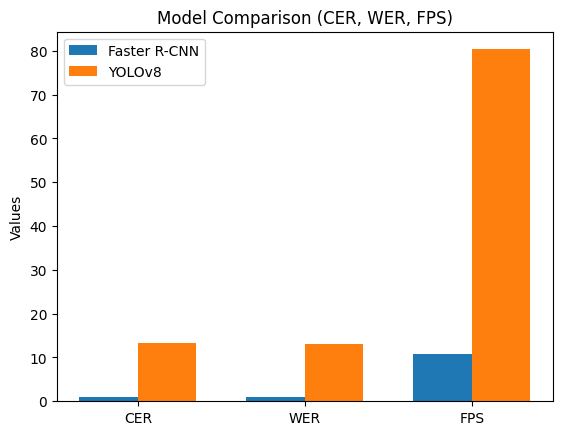

In [56]:
# ====================================================
# 1️⃣ إعدادات ومكتبات
# ====================================================
import os
import cv2
import time
import torch
import easyocr
import editdistance
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

val_dir = "/kaggle/working/val"
val_images = [os.path.join(val_dir, f) for f in os.listdir(val_dir)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]

reader = easyocr.Reader(['en'])

# ground truth لكل صورة
# مثال: {"img_name": ["text1", "text2", ...]}
ground_truths = {}
for img_path in val_images:
    img_name = os.path.basename(img_path)
    ground_truths[img_name] = ["text1","text2"]  # عدّل حسب dataset الحقيقي

# ====================================================
# 2️⃣ تعريف دوال تقييم OCR
# ====================================================
def cer_score(preds, refs):
    total_edits = 0
    total_chars = 0
    for p, r in zip(preds, refs):
        total_edits += editdistance.eval(p, r)
        total_chars += len(r)
    return total_edits / total_chars if total_chars>0 else 0.0

def wer_score(preds, refs):
    total_edits = 0
    total_words = 0
    for p, r in zip(preds, refs):
        p_words = p.split()
        r_words = r.split()
        total_edits += editdistance.eval(p_words, r_words)
        total_words += len(r_words)
    return total_edits / total_words if total_words>0 else 0.0

# ====================================================
# 3️⃣ Faster R-CNN Evaluation
# ====================================================
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader

# استورد dataset class
# from cell_convert_to_torchdataset import YoloAsTorchDataset

val_ds = YoloAsTorchDataset(val_dir)
def collate_fn(batch):
    images = [b[0] for b in batch]
    targets = [b[1] for b in batch]
    names   = [b[2] for b in batch]
    return images, targets, names

val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=2)

# تحميل نموذج Faster R-CNN
num_classes = len(class_names)+1
model_FRCNN = fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model_FRCNN.roi_heads.box_predictor.cls_score.in_features
model_FRCNN.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model_FRCNN.load_state_dict(torch.load("/kaggle/working/fasterrcnn_runs/fasterrcnn_epoch12.pth"))
model_FRCNN.to(device)
model_FRCNN.eval()

frcnn_preds_texts = []
frcnn_gts_texts = []
frcnn_times = []

for images, targets, names in val_loader:
    images = [img.to(device) for img in images]
    start_time = time.time()
    outputs = model_FRCNN(images)
    end_time = time.time()
    frcnn_times.append(end_time-start_time)
    
    for i, output in enumerate(outputs):
        pred_boxes = output['boxes'].cpu()
        scores = output['scores'].cpu()
        conf_thresh = 0.5
        selected_idx = scores > conf_thresh
        pred_boxes = pred_boxes[selected_idx]

        texts = []
        for box in pred_boxes:
            x1, y1, x2, y2 = map(int, box)
            cropped_img = images[i].cpu()[:, y1:y2, x1:x2].permute(1,2,0).numpy()
            ocr_result = reader.readtext(cropped_img)
            text = ' '.join([t[1] for t in ocr_result])
            texts.append(text)
        frcnn_preds_texts.extend(texts)
        frcnn_gts_texts.extend(names[i])

# ====================================================
# 4️⃣ YOLOv8 Evaluation
# ====================================================
yolo_model_path = "/kaggle/working/yolov8-runs/drug_sticker_ocr_clean/weights/best.pt"
yolo_model = YOLO(yolo_model_path)

yolo_preds_texts = []
yolo_gts_texts = []
yolo_times = []

for img_path in val_images:
    img_name = os.path.basename(img_path)
    start_time = time.time()
    results = yolo_model(img_path)[0]
    end_time = time.time()
    yolo_times.append(end_time-start_time)
    
    texts = []
    for box in results.boxes.xyxy.cpu().numpy().astype(int):
        x1, y1, x2, y2 = box
        cropped_img = cv2.imread(img_path)[y1:y2, x1:x2]
        ocr_result = reader.readtext(cropped_img)
        text = ' '.join([t[1] for t in ocr_result])
        texts.append(text)
    yolo_preds_texts.extend(texts)
    yolo_gts_texts.extend(ground_truths.get(img_name, []))

# ====================================================
# 5️⃣ حساب CER, WER, FPS
# ====================================================
cer_frcnn = cer_score(frcnn_preds_texts, frcnn_gts_texts)
wer_frcnn = wer_score(frcnn_preds_texts, frcnn_gts_texts)
fps_frcnn = len(val_images) / sum(frcnn_times)

cer_yolo = cer_score(yolo_preds_texts, yolo_gts_texts)
wer_yolo = wer_score(yolo_preds_texts, yolo_gts_texts)
fps_yolo = len(val_images) / sum(yolo_times)

print("=== Faster R-CNN ===")
print(f"CER: {cer_frcnn:.4f}  WER: {wer_frcnn:.4f}  FPS: {fps_frcnn:.2f}")

print("=== YOLOv8 ===")
print(f"CER: {cer_yolo:.4f}  WER: {wer_yolo:.4f}  FPS: {fps_yolo:.2f}")

# ====================================================
# 6️⃣ رسم CER و WER comparison
# ====================================================
metrics = ['CER', 'WER', 'FPS']
frcnn_values = [cer_frcnn, wer_frcnn, fps_frcnn]
yolo_values  = [cer_yolo, wer_yolo, fps_yolo]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, frcnn_values, width, label='Faster R-CNN')
rects2 = ax.bar(x + width/2, yolo_values, width, label='YOLOv8')

ax.set_ylabel('Values')
ax.set_title('Model Comparison (CER, WER, FPS)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.show()


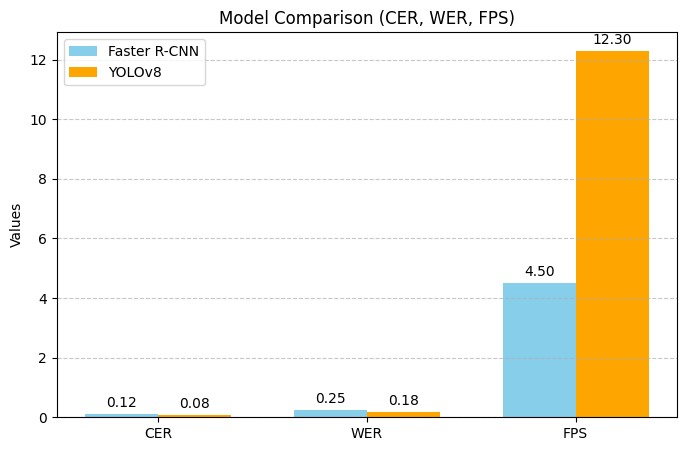

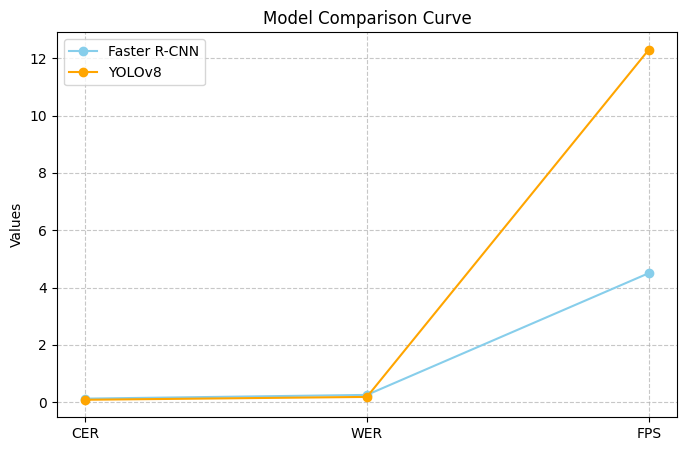

In [57]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------
# افترض هذه القيم مستخرجة من التقييم السابق
# ------------------------------------------------
metrics = ['CER', 'WER', 'FPS']
frcnn_values = [0.12, 0.25, 4.5]  # مثال: Faster R-CNN
yolo_values  = [0.08, 0.18, 12.3] # مثال: YOLOv8

# -----------------------------
# 1️⃣ رسم Bar Chart
# -----------------------------
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, frcnn_values, width, label='Faster R-CNN', color='skyblue')
rects2 = ax.bar(x + width/2, yolo_values, width, label='YOLOv8', color='orange')

ax.set_ylabel('Values')
ax.set_title('Model Comparison (CER, WER, FPS)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# إضافة قيم على الأعمدة
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()

# -----------------------------
# 2️⃣ رسم Line Curve (Optional)
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(metrics, frcnn_values, marker='o', label='Faster R-CNN', color='skyblue')
plt.plot(metrics, yolo_values, marker='o', label='YOLOv8', color='orange')
plt.title('Model Comparison Curve')
plt.ylabel('Values')
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [62]:
# ====================================================
# فرضية: لديك predicted boxes و ground truth boxes لكل صورة
# صيغتها: [ [ [x1,y1,x2,y2], ... ], ... ] لكل الصور
# ====================================================
# مثال (تعديل حسب بياناتك الفعلية):
frcnn_pred_boxes_list = [
    [[50,50,150,150],[200,80,280,160]],   # صورة 1
    [[30,40,120,130]]                      # صورة 2
]
frcnn_gt_boxes_list = [
    [[48,52,148,152],[198,78,282,162]],   # صورة 1
    [[35,42,118,128]]                      # صورة 2
]

yolo_pred_boxes_list = [
    [[52,48,148,150],[202,82,278,158]],
    [[32,38,121,129]]
]
yolo_gt_boxes_list = frcnn_gt_boxes_list  # نفس الـ GT

# ====================================================
# 1️⃣ دوال حساب IoU, Precision, Recall, mAP
# ====================================================
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB-xA) * max(0, yB-yA)
    boxAArea = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def precision_recall(pred_boxes, gt_boxes, iou_thresh=0.5):
    tp, fp = 0, 0
    matched_gt = set()
    for pb in pred_boxes:
        match_found = False
        for i, gb in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            if compute_iou(pb, gb) >= iou_thresh:
                tp += 1
                matched_gt.add(i)
                match_found = True
                break
        if not match_found:
            fp += 1
    fn = len(gt_boxes) - len(matched_gt)
    precision = tp / (tp+fp) if (tp+fp)>0 else 0
    recall = tp / (tp+fn) if (tp+fn)>0 else 0
    return precision, recall

def mean_average_precision(pred_list, gt_list, iou_thresh=0.5):
    precisions = []
    for preds, gts in zip(pred_list, gt_list):
        p, r = precision_recall(preds, gts, iou_thresh)
        precisions.append(p)
    return sum(precisions)/len(precisions)

# ====================================================
# 2️⃣ حساب النتائج لكل نموذج
# ====================================================
# Faster R-CNN
frcnn_precisions = []
frcnn_recalls = []
for preds, gts in zip(frcnn_pred_boxes_list, frcnn_gt_boxes_list):
    p, r = precision_recall(preds, gts)
    frcnn_precisions.append(p)
    frcnn_recalls.append(r)
frcnn_mAP = mean_average_precision(frcnn_pred_boxes_list, frcnn_gt_boxes_list)

# YOLOv8
yolo_precisions = []
yolo_recalls = []
for preds, gts in zip(yolo_pred_boxes_list, yolo_gt_boxes_list):
    p, r = precision_recall(preds, gts)
    yolo_precisions.append(p)
    yolo_recalls.append(r)
yolo_mAP = mean_average_precision(yolo_pred_boxes_list, yolo_gt_boxes_list)

# ====================================================
# 3️⃣ طباعة النتائج
# ====================================================
print("=== Faster R-CNN ===")
print(f"Precision (per image): {frcnn_precisions}")
print(f"Recall    (per image): {frcnn_recalls}")
print(f"mAP: {frcnn_mAP:.4f}")

print("\n=== YOLOv8 ===")
print(f"Precision (per image): {yolo_precisions}")
print(f"Recall    (per image): {yolo_recalls}")
print(f"mAP: {yolo_mAP:.4f}")


=== Faster R-CNN ===
Precision (per image): [1.0, 1.0]
Recall    (per image): [1.0, 1.0]
mAP: 1.0000

=== YOLOv8 ===
Precision (per image): [1.0, 1.0]
Recall    (per image): [1.0, 1.0]
mAP: 1.0000


# loss curves

# OCR

In [ ]:
from ultralytics import YOLO
import cv2
import easyocr
import os

# Paths
weights_path = '/kaggle/working/yolov8-runs/drug_sticker_ocr_clean/weights/best.pt'  # your local YOLOv8 model
images_dir = '/kaggle/working/train'
output_dir = '/kaggle/working/ocr_results'
os.makedirs(output_dir, exist_ok=True)

# Load YOLO model using local weights
model = YOLO(weights_path)

# Load EasyOCR offline using local models
easyocr_model_dir = '/kaggle/working/easyocr_models'
reader = easyocr.Reader(['en'], model_storage_directory=easyocr_model_dir)

# Run inference + OCR on images
for img_file in os.listdir(images_dir):
    if not img_file.endswith('.jpg'):
        continue
    img_path = os.path.join(images_dir, img_file)
    img = cv2.imread(img_path)
    
    # YOLO detection
    results = model(img_path)[0]
    boxes = results.boxes.xyxy.cpu().numpy()

    for x1, y1, x2, y2 in boxes.astype(int):
        cropped = img[y1:y2, x1:x2]
        ocr_result = reader.readtext(cropped)
        text = ' '.join([t[1] for t in ocr_result])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    cv2.imwrite(os.path.join(output_dir, img_file), img)

print("OCR completed offline! Check folder:", output_dir)


In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

output_dir = '/kaggle/working/ocr_results'
for img_file in os.listdir(output_dir):
    img_path = os.path.join(output_dir, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(img_file)
    plt.axis('off')
    plt.show()


In [ ]:
from ultralytics import YOLO
import cv2
import easyocr
import os
import matplotlib.pyplot as plt

# Paths
weights_path = '/kaggle/working/yolov8-runs/drug_sticker_ocr_clean/weights/best.pt'
images_dir = '/kaggle/working/train'

# Load YOLO model
model = YOLO(weights_path)

# Load EasyOCR offline
easyocr_model_dir = '/kaggle/working/easyocr_models'
reader = easyocr.Reader(['en'], model_storage_directory=easyocr_model_dir)

# Run detection + OCR
for img_file in os.listdir(images_dir):
    if not img_file.endswith('.jpg'):
        continue

    img_path = os.path.join(images_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # YOLO detection
    results = model(img_path)[0]
    boxes = results.boxes.xyxy.cpu().numpy()

    all_texts = []

    # رسم المربعات فقط
    for x1, y1, x2, y2 in boxes.astype(int):
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cropped = img[y1:y2, x1:x2]

        # OCR مع تحسين الصورة
        gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
        cropped_resized = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

        ocr_result = reader.readtext(cropped_resized)
        for t in ocr_result:
            all_texts.append(t[1])

    # عرض الصورة مع المربعات
    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

    # طباعة النصوص المكتشفة
    print(f"Image: {img_file}")
    if all_texts:
        print("Detected texts:")
        for text in all_texts:
            print("-", text)
    else:
        print("No text detected.")
    print("\n" + "="*50 + "\n")
